In [64]:
import os
import pickle
import glob
import numpy as np
import matplotlib.pyplot as plt

In [65]:
RESULTS_DIR = 'results/mnist_ae_local'

results = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, 'result_*.pkl'))):
    with open(path, 'rb') as f:
        results.append(pickle.load(f))

print(f'Loaded {len(results)} result(s)')
print('Keys:', list(results[0].keys()) if results else 'none')

Loaded 1 result(s)
Keys: ['n_b', 'n_d', 'm', 'seed', 'model_name', 'recon_train', 'recon_test', 'train_error', 'gen_error', 'probe_losses']


## AE training loss trajectory

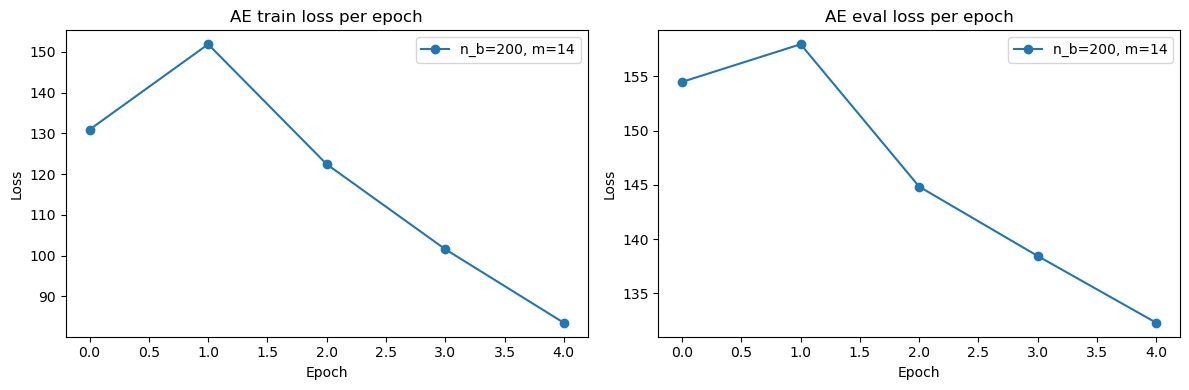

In [66]:
import json

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r in results:
    label = f"n_b={r['n_b']}, m={r['m']}"
    ae_output_dir = os.path.join(RESULTS_DIR, f"ae_nb{r['n_b']}_m{r['m']}_seed{r['seed']}")

    if not os.path.isdir(ae_output_dir):
        print(f"Missing ae_output_dir for {label}")
        continue

    runs = sorted(os.listdir(ae_output_dir))
    if not runs:
        print(f"No runs found for {label}")
        continue

    ae_losses_path = os.path.join(ae_output_dir, runs[-1], 'final_model', 'ae_losses.json')
    if not os.path.exists(ae_losses_path):
        print(f"No ae_losses.json for {label} (looked in {ae_losses_path})")
        continue

    with open(ae_losses_path) as f:
        saved = json.load(f)
    ae_train = saved.get('ae_train_losses') or []
    ae_eval  = saved.get('ae_eval_losses') or []

    if ae_train:
        axes[0].plot(ae_train, marker='o', label=label)
    if ae_eval:
        axes[1].plot(ae_eval, marker='o', label=label)

axes[0].set_title('AE train loss per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('AE eval loss per epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## AE reconstruction error (final)

In [67]:
for r in results:
    print(f"n_b={r['n_b']:5d}  m={r['m']:4d}  "
          f"recon_train={r['recon_train']:.6f}  recon_test={r['recon_test']:.6f}")

n_b=  200  m=  14  recon_train=0.327996  recon_test=0.328461


## Linear probe loss trajectory

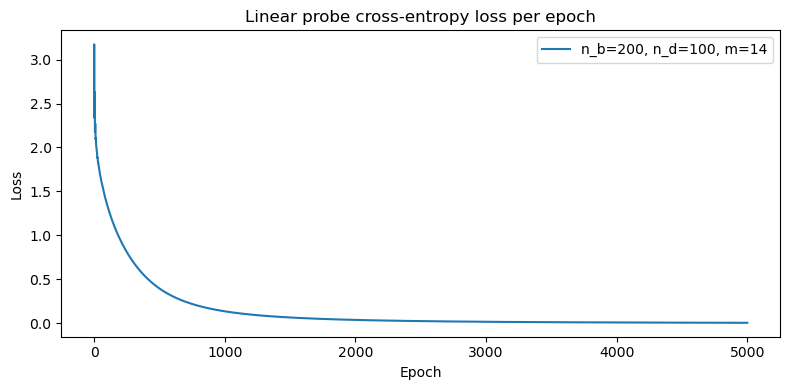

In [68]:
fig, ax = plt.subplots(figsize=(8, 4))

for r in results:
    if r.get('probe_losses'):
        label = f"n_b={r['n_b']}, n_d={r['n_d']}, m={r['m']}"
        ax.plot(r['probe_losses'], label=label)

ax.set_title('Linear probe cross-entropy loss per epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

## Linear probe final errors

In [69]:
for r in results:
    print(f"n_b={r['n_b']:5d}  n_d={r['n_d']:5d}  m={r['m']:4d}  "
          f"train_err={r['train_error']:.4f}  gen_err={r['gen_error']:.4f}")

n_b=  200  n_d=  100  m=  14  train_err=0.0000  gen_err=0.8646


## Summary: train vs generalisation error

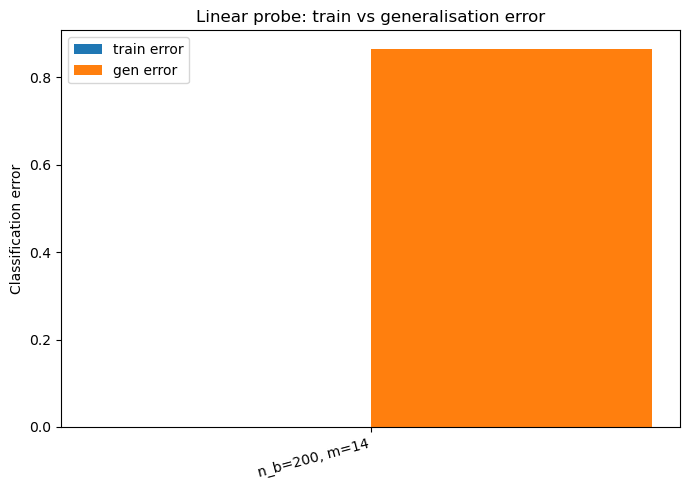

In [70]:
fig, ax = plt.subplots(figsize=(7, 5))

train_errs = [r['train_error'] for r in results]
gen_errs   = [r['gen_error']   for r in results]
labels     = [f"n_b={r['n_b']}, m={r['m']}" for r in results]

x = np.arange(len(results))
width = 0.35
ax.bar(x - width/2, train_errs, width, label='train error')
ax.bar(x + width/2, gen_errs,   width, label='gen error')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Classification error')
ax.set_title('Linear probe: train vs generalisation error')
ax.legend()
plt.tight_layout()
plt.show()